# P-values and confidence intervals on coefficient estimates in linear regression

Knowing the estimates of coefficients for each input variable in a linear regression model is a good way to quantify the relationship between the input variable and an outcome variable. But it's important to consider the model's uncertainty about those estimates! We'll dig into that uncertainty, expressed as p-values and confidence intervals, here.

First we'll recreate the same model predicting food truck profit from city population size.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
profits = pd.read_csv('https://raw.githubusercontent.com/girishkuniyal/Predict-Profit-for-food-truck/refs/heads/master/ex1data1.txt',
                    header=None,
                    names=['population', 'profit'])
profits.info()
profits.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   population  97 non-null     float64
 1   profit      97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB


,population,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


Let's fit a linear regression model and get coefficient estimates for the `population` input variable (the slope) and the intercept, which is the estimated value of the output assuming a population of 0.

In [3]:
model = smf.ols(formula = 'profit ~ population', data=profits).fit()
model.params

Intercept    -3.895781
population    1.193034
dtype: float64

## Confidence intervals on coefficient estimates

Recall that linear regression's coefficient estimates are estimates for the mean output across a range of input values. Just like when we were estimating the means of samples, these coefficient estimates have a standard error!

In [4]:
model.bse

Intercept     0.719483
population    0.079744
dtype: float64

The 95% confidence interval is approximately equal to 2 times the standard error (which is the standard deviation of the normal distribution of estimated means). Actual bounds of the 95% confidence interval are available with the `.conf_int()` function. The lower bound of the interval, in column `0`, is approximately 2 times the standard error lower than the coeffienct estimate. The upper bound, column `1`, is 2 times the standard error higher than the coefficient estimate.

In [5]:
model.conf_int()

,0,1
Intercept,-5.324135,-2.467427
population,1.034722,1.351345


## P-values on coefficient estimates

Depending on how much data we have, there's a chance our 95% confidence interval includes a value of 0. A coefficient of 0 would mean there's no relationship between the input variable and the output variable. 

P-values represent the chance of this "null hypothesis" that the true coefficient is 0. If the p-value for a coefficient estimate is low (< 0.05), that means we can be confident that the coefficient is not 0 and the association we see between the input and output is statistically significant. With a p-value less than 0.05, if the coefficient is positive, we can be confident that the true relationship is positive. Or if it's negative, we can be confident that the true relationship is a negative association.

We can extract the p-values from a fitted `statsmodel` linear regression model with `.pvalues`.

In [6]:
model.pvalues

Intercept     4.607887e-07
population    1.023210e-26
dtype: float64

## Visualize confidence intervals on coefficients
Visualizing the 95% confidence intervals allows us to see if the confidence interval contains 0. If it does, then that means the p-values is >0.05 and we can't be confident that the true coefficient isn't 0. If the confidence interval on the coefficient doesn't contain 0, the p-value is less than 0 and we can be confident about the sign of the coefficient.

We'll use Seaborn and Matplotlib to plot the coefficient estimates as points with confidence intervals as error bars.

In [7]:
coef_info = model.conf_int().rename(columns={0: 'ci_lower', 1: 'ci_upper'})
coef_info['coef'] = model.params
coef_info

,ci_lower,ci_upper,coef
Intercept,-5.324135,-2.467427,-3.895781
population,1.034722,1.351345,1.193034


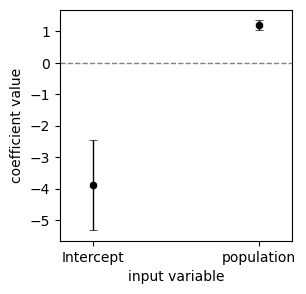

In [8]:
fig, ax = plt.subplots(figsize=(3,3))
ax.margins(x=0.2) # adjusts whitespace around x-axis

# Plot coefficients and bounds on the confidence intervals
sns.scatterplot(data=coef_info, x=coef_info.index, y='ci_lower', color='black', marker='_', ax=ax)
sns.scatterplot(data=coef_info, x=coef_info.index, y='coef', color='black', marker='o', ax=ax)
sns.scatterplot(data=coef_info, x=coef_info.index, y='ci_upper', color='black', marker='_', ax=ax)

# Confidence intervals as line segments
ax.vlines(x=coef_info.index, ymin=coef_info['ci_lower'], ymax=coef_info['ci_upper'], color='black', linewidth=1)

# Horizontal reference line at 0
ax.axhline(y=0, linestyle='--', linewidth=1, color='gray')

ax.set_xlabel('input variable')
ax.set_ylabel('coefficient value')
plt.show()